In [161]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

print_flag = False 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if print_flag :
             print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## EVERYTHING IMPORT SECTION

In [162]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import re
import random
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

from PIL import Image
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences   
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.layers import Input , Dense , LSTM , Embedding , Dropout , add
print("All modules imported")

All modules imported


## BASE AND WORKING DIR 

In [163]:
BASE_DIR = '/kaggle/input/flickr8k'
WORKING_DIR = '/kaggle/working'
print("ok")

ok


# CAPTION PREPROCESSING 

## Load Caption Data
* caption.txt ke load korbo code e so that we can use 

In [164]:

with open(os.path.join(BASE_DIR, 'captions.txt'),'r') as f:
    next(f)
    captions_doc = f.read()

print("ok")


ok


## Mapping
* each image er jonne thaka camption age image er shathe map korte hobe karon Flickr8k te image ar caption duita alada file 

In [165]:
# image er naam hocche {id.jpg} and caption er format hocce imageId , caption 
# example - 1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .

map_caption_to_image = {}

for line in tqdm(captions_doc.split('\n')):
    tokens = line.split(',')

    if len(line) < 2: 
        continue  
    image_id , caption = tokens[0] , tokens[1:]  # aw image_id exract korlam 1000268201_693b08cb0e.jpg 
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)

    if image_id not in map_caption_to_image :
        map_caption_to_image[image_id] = [] # ekdom new asha image_id er jonne fresh array nilam 
                               # age theke image_id  exist kora mane oi image er ekadhik caption ase so ei if block e dhukbe na rather ager banano array the append hbe new asha caption 
    map_caption_to_image[image_id].append(caption)


  0%|          | 0/40456 [00:00<?, ?it/s]

In [166]:
len(map_caption_to_image)

8091

* Caption nana dhoroner ase dataset e so we gonna clen it hence the function clean

In [167]:
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]

            caption = caption.lower()

            
            caption = re.sub(r'[^a-z]', ' ', caption)
            caption = re.sub(r'\s+', ' ', caption).strip()


            caption = 'startseq ' + " ".join( 
                [word for word in caption.split() if len(word) > 1]
            ) + ' endseq'
            captions[i] = caption # clean caption
    

* All captions clean korlam 

In [168]:
# print(map_caption_to_image['1000268201_693b08cb0e'])
# clean(map_caption_to_image)
# print(map_caption_to_image['1000268201_693b08cb0e'])


In [169]:
clean(map_caption_to_image)

all_captions = []
for key in map_caption_to_image:
    for caption in map_caption_to_image[key]:
        all_captions.append(caption)

In [170]:
# all_captions

# MODEL

In [171]:
model_vgg = VGG16()
model_vgg = Model(
    inputs=model_vgg.inputs,
    outputs=model_vgg.layers[-2].output
)


# FEATURE EXTRACTION

In [172]:
features = {}
directory = os.path.join(BASE_DIR , 'Images')

for img_name in tqdm(os.listdir(directory)):
    #load the image from file
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    #convert the image to array 
    image = img_to_array(image)
    #reshape data for model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))     #rgb tai 3 dimension
    #prepare the image for the vgg model    
    image = preprocess_input(image)
    #get features
    feature = model_vgg.predict(image, verbose=0)
    #get image id
    image_id = img_name.split('.')[0]
    #store feature
    features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

In [173]:
pickle.dump(features , open(os.path.join(WORKING_DIR, 'features.pkl'),'wb'))
with open(os.path.join(WORKING_DIR, 'features.pkl'),'rb') as f:
    features = pickle.load(f)
    

# TOKENIZE

In [174]:
# all caption er proti ta word ke ekta kore number dbo

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

#print("vocab_size : "+ vocab_size)
# max_length = max(len(caption.split()) for caption in all_captions)
# max_length

# Split

In [175]:
image_ids = list(map_caption_to_image.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [176]:
all_captions[:10]
vocab_size

8427

In [177]:
max_length = max(len(caption.split()) for caption in all_captions)
max_length

35

In [178]:
# import tensorflow as tf

# def tf_caption_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size):
#     for key in data_keys:
#         captions = mapping[key]
#         for caption in captions:
#             seq = tokenizer.texts_to_sequences([caption])[0]
#             for i in range(1, len(seq)):
#                 in_seq, out_seq = seq[:i], seq[i]
#                 in_seq = tf.keras.preprocessing.sequence.pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
#                 in_seq = np.array(in_seq, dtype=np.int32)
#                 out_seq = tf.keras.utils.to_categorical(out_seq, num_classes=vocab_size)
#                 yield (features[key][0], in_seq), out_seq


In [179]:
# output_signature = (
#     (
#         tf.TensorSpec(shape=(4096,), dtype=tf.float32),  # image features
#         tf.TensorSpec(shape=(max_length,), dtype=tf.int32)  # caption sequence
#     ),
#     tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)  # next word
# )


In [180]:
# train_dataset = tf.data.Dataset.from_generator(
#     lambda: tf_caption_generator(
#         train_ids,
#         map_caption_to_image,
#         features,
#         tokenizer,
#         max_length,
#         vocab_size
#     ),
#     output_signature=output_signature
# )

# train_dataset = train_dataset.repeat().batch(32)

# steps_per_epoch = len(train_ids) * 5 // 32




In [181]:
breed_processor = AutoImageProcessor.from_pretrained(
    "wesleyacheng/dog-breeds-multiclass-image-classification-with-vit"
)

breed_model = AutoModelForImageClassification.from_pretrained(
    "wesleyacheng/dog-breeds-multiclass-image-classification-with-vit"
)

breed_model.eval()


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

# Model_Creation_C

In [182]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, map_caption_to_image, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = map_caption_to_image[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq],num_classes=vocab_size)[0]
                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield (X1, X2), y
                X1, X2, y = list(), list(), list()
                n = 0


# encoder model
# image feature layers
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)
# train the model
epochs = 2
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # create data generator
    generator = data_generator(train, map_caption_to_image, features, tokenizer, max_length, vocab_size, batch_size)
    # fit for one epoch
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 207ms/step - loss: 5.7836
227/227 ━━━━━━━━━━━━━━━━━━━━ 47s 206ms/step - loss: 4.0470


# MODEL CREATION

## Encoder Model


In [183]:
# inputs1 = Input(shape=(4096,))
# feature_encoder1 = Dropout(0.4)(inputs1)
# feature_encoder2 = Dense(256, activation  = 'relu')(feature_encoder1)


# inputs2 = Input(shape=(max_length,))
# seq_embedding = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
# seq_dropout = Dropout(0.4)(seq_embedding)
# seq_lstm = LSTM(256)(seq_dropout)


## Decoder Model

In [184]:
# decoder1 = add([feature_encoder2 , seq_lstm])
# decoder2 = Dense(vocab_size , activation = 'softmax')(decoder1)
# outputs = Dense(vocab_size , activation = 'softmax')(decoder2)


# model = Model(inputs=[inputs1, inputs2], outputs=outputs)
# model.compile(loss='categorical_crossentropy',optimizer='adam')

# # plot_model(model, show_shapes=True)


In [185]:
model.save(WORKING_DIR+'/best_model.h5')

# TRAIN MODEL

In [186]:
# model.fit(
#     train_dataset,
#     epochs=2,
#     steps_per_epoch=steps_per_epoch,
#     verbose=1
# )

# GENERATE CAPTION FOR IMAGE

In [187]:
def idx_to_word(integer,tokenizer):
    for word , index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [188]:
def predict_dog_breed(img_path):
    image = Image.open(img_path).convert("RGB")
    inputs = breed_processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = breed_model(**inputs)

    idx = outputs.logits.argmax(-1).item()
    return breed_model.config.id2label[idx]


* predicted index ke word e nicchi

In [189]:
def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'

    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)

        word = tokenizer.index_word.get(yhat)
        if word is None:
            break

        in_text += " " + word

        if word == 'endseq':
            break

    return in_text


# Result Visualization

In [190]:
# def generate_caption(image_name):
#     image_id = image_name.split('.')[0]
#     img_path = os.path.join(BASE_DIR, "Images", image_name)
#     image = Image.open(img_path)
#     captions = map_caption_to_image[image_id]
#     print('---------------------Actual---------------------')
#     for caption in captions:
#         print(caption)

    
#     # predict the caption
#     y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
#     breed = predict_dog_breed(img_path)
#     print(breed)
#     if "dog" in y_pred:
#         y_pred = y_pred.replace("dog", breed.replace("_", " "))
#     else:
#         y_pred = y_pred.replace("startseq", f"startseq {breed.replace('_', ' ')}")

#     print('--------------------Predicted--------------------')
#     print(y_pred)
#     plt.imshow(image)
#     return breed

In [191]:
# breedy = generate_caption("1022975728_75515238d8.jpg")
# print(breedy)

In [192]:
max_length

35

In [193]:
# from tensorflow.keras.models import load_model

# model = load_model(WORKING_DIR + '/best_model.h5')

# print("Model Loaded Successfully!")

# OUTSIDE DATA 

## Upload image from outside 

In [221]:
def extract_features_external(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    feature = model_vgg.predict(image, verbose=0)
    return feature

def extract_features_external(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    feature = model_vgg.predict(image, verbose=0)
    return feature



# def generate_caption_external(image_path):
#     # Step 1: extract CNN features
#     feature = extract_features_external(image_path)

#     # Step 2: generate base caption
#     caption = predict_caption(model, feature, tokenizer, max_length)

#     # Step 3: detect dog breed
#     breed = predict_dog_breed(image_path).replace("_", " ")

#     # Step 4: entity injection
#     if "dog" in caption:
#         caption = caption.replace("dog", breed)
#     else:
#         caption = caption.replace("startseq", f"startseq {breed}")

#     return caption




# caption = generate_caption_external(
#     "/kaggle/input/outsidedataset/bichon.jpeg"
# )
# print(caption)

def generate_caption_external(image_path):
    # Step 1: extract CNN features
    feature = extract_features_external(image_path)

    # Step 2: generate base caption
    caption = predict_caption(model, feature, tokenizer, max_length)

    # Step 3: detect dog breed with confidence check
    image = Image.open(image_path).convert("RGB")
    inputs = breed_processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = breed_model(**inputs)
    
    # কনফিডেন্স স্কোর বের করা
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    confidence, idx = torch.max(probs, dim=-1)
    
    # যদি মডেল ৬০% (0.6) এর বেশি নিশ্চিত হয় তবেই ব্রিড পাল্টাবে
    if confidence.item() > 0.1:
        breed = breed_model.config.id2label[idx.item()].replace("_", " ")
        
        # Step 4: entity injection
        if "dog" in caption:
            caption = caption.replace("dog", breed)
        else:
            # যদি ক্যাপশনে dog না থাকে কিন্তু মডেল নিশ্চিত কুকুর, তবেই শুরুতে ব্রিড বসাবে
            caption = caption.replace("startseq", f"startseq {breed}")
    
    # অপ্রয়োজনীয় ট্যাগ পরিষ্কার করা
    caption = caption.replace('startseq', '').replace('endseq', '').strip()
    
    return caption




caption = generate_caption_external(
    "/kaggle/input/outsidedataset/bichon.jpeg"
)
print(caption)



white maltese dog is running in the grass


In [230]:
from IPython.display import display
from ipywidgets import FileUpload
import os

upload = FileUpload(accept='image/*', multiple=False)
display(upload)




FileUpload(value=(), accept='image/*', description='Upload')


PREDICTED: siberian husky is running in the snow


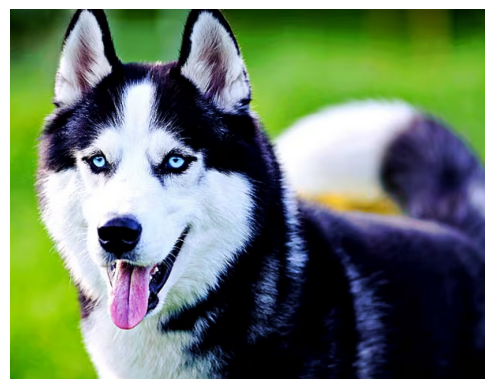

In [231]:
import os
from PIL import Image
import matplotlib.pyplot as plt

if len(upload.value) > 0:
    file_info = upload.value[0] 
    
    uploaded_filename = file_info['name']
    content = file_info['content']
    
    save_path = os.path.join('/kaggle/working', 'dynamic_test.jpg')
    with open(save_path, 'wb') as f:
        f.write(content)
    
    
    result = generate_caption_external(save_path)
    
    print("\n" + "="*40)
    print(f"PREDICTED: {result.replace('startseq', '').replace('endseq', '')}")
    print("="*40)
    
    img = Image.open(save_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Upload pic first!")